# Understanding data

This notebook is dedicated to understanding the data provided.

In [1]:
from pathlib import Path

data_dir = Path('../input/jane-street-real-time-market-data-forecasting')

## Step 1: Loading training

Let's spend sometime understanding how the training set is structured.

In [2]:
import pandas as pd

for partition in range(0, 10):
    location = data_dir / f'train.parquet/partition_id={partition}/part-0.parquet'
    df = pd.read_parquet(location, columns=['date_id'])
    min_date, max_date = df['date_id'].min(), df['date_id'].max()
    print(f"Partition {partition}:")
    print(f"\tMin = {min_date}")
    print(f"\tMax = {max_date}")
    print('=' * 120)

Partition 0:
	Min = 0
	Max = 169
Partition 1:
	Min = 170
	Max = 339
Partition 2:
	Min = 340
	Max = 509
Partition 3:
	Min = 510
	Max = 679
Partition 4:
	Min = 680
	Max = 849
Partition 5:
	Min = 850
	Max = 1019
Partition 6:
	Min = 1020
	Max = 1189
Partition 7:
	Min = 1190
	Max = 1359
Partition 8:
	Min = 1360
	Max = 1529
Partition 9:
	Min = 1530
	Max = 1698


These results indicate that there is no overlap in dates between partitions, and that they follow a chronological ordering. 

Let's then investigate some of the details only for partition 0.

In [3]:
train_0 = pd.read_parquet(data_dir / 'train.parquet/partition_id=0/part-0.parquet')

train_0.sort_values(by=['date_id', 'time_id'], inplace=True)

In [4]:
train_0.head(5)

,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,...,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
0,0,0,1,3.889038,NaN,NaN,NaN,NaN,NaN,0.851033,...,-0.281498,0.738489,-0.069556,1.380875,2.005353,0.186018,1.218368,0.775981,0.346999,0.095504
1,0,0,7,1.370613,NaN,NaN,NaN,NaN,NaN,0.676961,...,-0.302441,2.965889,1.190077,-0.523998,3.849921,2.626981,5.000000,0.703665,0.216683,0.778639
2,0,0,9,2.285698,NaN,NaN,NaN,NaN,NaN,1.056285,...,-0.096792,-0.864488,-0.280303,-0.326697,0.375781,1.271291,0.099793,2.109352,0.670881,0.772828
3,0,0,10,0.690606,NaN,NaN,NaN,NaN,NaN,1.139366,...,-0.296244,0.408499,0.223992,2.294888,1.097444,1.225872,1.225376,1.114137,0.775199,-1.379516
4,0,0,14,0.440570,NaN,NaN,NaN,NaN,NaN,0.955200,...,3.418133,-0.373387,-0.502764,-0.348021,-3.928148,-1.591366,-5.000000,-3.572820,-1.089123,-5.000000


## Step 2: Quick overlook on `responder_6`

Let's see if there is any considerable shift in the responder as a function of date.

In [5]:
daily = train_0.groupby('date_id')
r6_daily_avg = daily['responder_6'].mean()
r6_daily_std = daily['responder_6'].std()

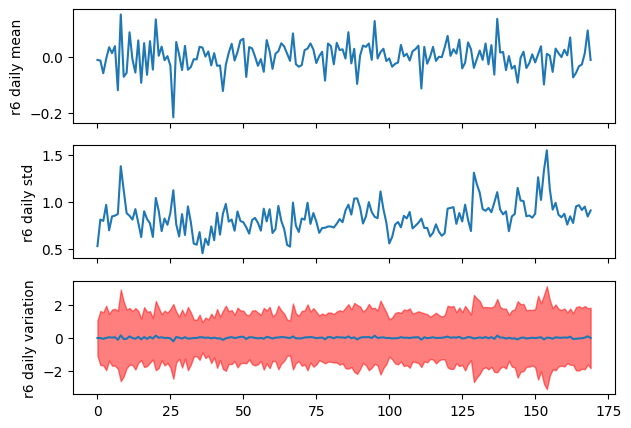

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, sharex='col', figsize=(7, 5))
axes[0].set_ylabel('r6 daily mean')
axes[1].set_ylabel('r6 daily std')
axes[2].set_ylabel('r6 daily variation')

axes[0].plot(r6_daily_avg)
axes[1].plot(r6_daily_std)
_ = axes[-1].fill_between(range(len(r6_daily_avg)),
                          r6_daily_avg + 2 * r6_daily_std,
                          r6_daily_avg - 2 * r6_daily_std,
                          color='red',
                          alpha=0.5)
_ = axes[-1].plot(r6_daily_avg)

## Step 3: Quick check on features

Now, let's take a look at some other statistics

In [7]:
# assuming df is partition 0
print("Dates:", train_0["date_id"].nunique())
print("Time per date:")
print(train_0.groupby("date_id")["time_id"].nunique().describe())

print("Symbols per timestep:")
print(train_0.groupby(["date_id","time_id"])["symbol_id"].nunique().describe())

print("Feature stats (first 10 features):")
print(train_0[[f"feature_{i:02d}" for i in range(10)]].describe())

print("Target stats:")
print(train_0["responder_6"].describe())

print("Weight stats:")
print(train_0["weight"].describe())

Dates: 170
Time per date:
count    170.0
mean     849.0
std        0.0
min      849.0
25%      849.0
50%      849.0
75%      849.0
max      849.0
Name: time_id, dtype: float64
Symbols per timestep:
count    144330.000000
mean         13.470588
std           3.252479
min           4.000000
25%          11.000000
50%          13.500000
75%          16.000000
max          20.000000
Name: symbol_id, dtype: float64
Feature stats (first 10 features):
       feature_00  feature_01  feature_02  feature_03  feature_04  \
count         0.0         0.0         0.0         0.0         0.0   
mean          NaN         NaN         NaN         NaN         NaN   
std           NaN         NaN         NaN         NaN         NaN   
min           NaN         NaN         NaN         NaN         NaN   
25%           NaN         NaN         NaN         NaN         NaN   
50%           NaN         NaN         NaN         NaN         NaN   
75%           NaN         NaN         NaN         NaN         NaN   

It appears some features are all `NaN`. Let's get a better understanding of how often we have missing information.

In [8]:
# list of all feature columns
feature_cols = [f"feature_{i:02d}" for i in range(79)]

# compute fraction of NaNs per feature
nan_fraction_per_feature = train_0[feature_cols].isna().mean()
nan_fraction_per_feature.sort_values(ascending=False, inplace=True)

# display nicely
for feature, frac in nan_fraction_per_feature.items():
    print(f"{feature}: {frac*100:.1f}%")

feature_00: 100.0%
feature_21: 100.0%
feature_02: 100.0%
feature_03: 100.0%
feature_04: 100.0%
feature_01: 100.0%
feature_31: 100.0%
feature_27: 100.0%
feature_26: 100.0%
feature_42: 16.7%
feature_39: 16.7%
feature_53: 15.1%
feature_50: 15.1%
feature_66: 8.6%
feature_46: 8.6%
feature_65: 8.6%
feature_45: 8.6%
feature_62: 7.9%
feature_64: 7.0%
feature_63: 6.9%
feature_44: 5.0%
feature_41: 5.0%
feature_52: 3.3%
feature_55: 3.3%
feature_15: 2.8%
feature_43: 2.0%
feature_40: 2.0%
feature_33: 1.1%
feature_32: 1.1%
feature_58: 1.1%
feature_73: 1.1%
feature_74: 1.1%
feature_08: 0.9%
feature_17: 0.5%
feature_54: 0.1%
feature_51: 0.1%
feature_47: 0.0%
feature_16: 0.0%
feature_57: 0.0%
feature_19: 0.0%
feature_18: 0.0%
feature_56: 0.0%
feature_75: 0.0%
feature_76: 0.0%
feature_77: 0.0%
feature_67: 0.0%
feature_71: 0.0%
feature_59: 0.0%
feature_60: 0.0%
feature_61: 0.0%
feature_70: 0.0%
feature_69: 0.0%
feature_68: 0.0%
feature_72: 0.0%
feature_11: 0.0%
feature_49: 0.0%
feature_48: 0.0%
feature_1

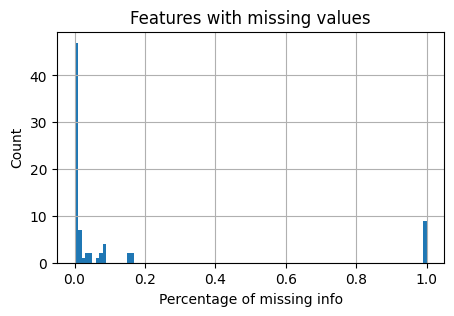

In [9]:
import numpy as np

axes = nan_fraction_per_feature.hist(bins=np.arange(0., 1.01, 0.01).tolist())
axes.set_ylabel('Count')
axes.set_xlabel('Percentage of missing info')
axes.set_title('Features with missing values')

fig = axes.get_figure()
fig.set_size_inches(5, 3)

As we can see, there are a number of features with missing information. In particular, they appear to be in one of four categories:
- fully missing (can be discarded)
- ~15% of entries missing (needs imputation and possibly a missing-value flag)
- ~8% of entries missing (needs imputation and possibly missing-value flag)
- <5% missing entries (needs imputation, likely ok without missing-value flag)

## Step 4: Understand responder dynamics based on symbol

### Step 4.1: Look at total `symbol_id` counts

Let's first see how many different symbols we have, and how many of each.

In [10]:
symbol_counts = train_0["symbol_id"].value_counts()

In [11]:
print(symbol_counts.describe())

count        20.000000
mean      97210.500000
std       41222.655494
min       20376.000000
25%       60915.750000
50%      109521.000000
75%      138387.000000
max      143481.000000
Name: count, dtype: float64


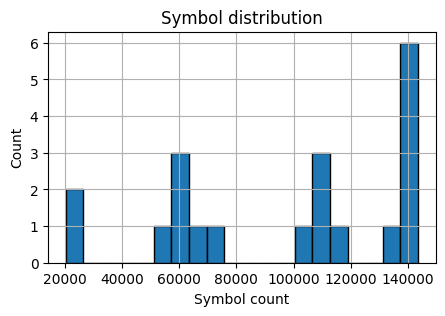

In [12]:
axes = symbol_counts.hist(bins=20, edgecolor='k')
axes.set_ylabel('Count')
axes.set_xlabel('Symbol count')
axes.set_title('Symbol distribution')

fig = axes.get_figure()
fig.set_size_inches(5, 3)

We can see that symbols appear at varying rates, but even with 20k responses, we should have enough for modeling.

### Step 4.2: Responder distribution by symbol

Let's now evaluate how the distribution of the responder varies by symbol.

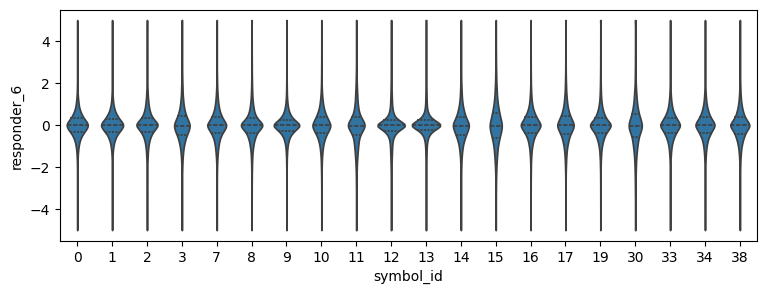

In [13]:
import seaborn as sns

axes = sns.violinplot(data=train_0, x='symbol_id', y='responder_6',
                      inner='quart',
                      # bw_adjust=0.5,
                      # native_scale=True,
                      cut=0)

fig = axes.get_figure()
fig.set_figheight(3)
fig.set_figwidth(9)

It appears that these distributions are somewhat different... Let's see if we can zoom-in a bit where the data is concentrated

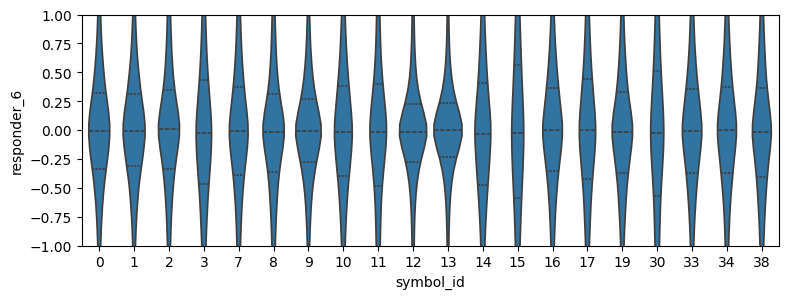

In [14]:
axes.set_ylim([-1, 1])
axes.get_figure()

Indeed, we see that some of these are skinnier, while some are more concentrated around the mean. 

In [15]:
symbol_stats = train_0.groupby("symbol_id")["responder_6"].agg(
    ["mean", "std", "min", "max", "count"]
)

In [16]:
symbol_stats.describe()

,mean,std,min,max,count
count,20.000000,20.000000,20.0,20.0,20.000000
mean,0.001055,0.914534,-5.0,5.0,97210.500000
std,0.018717,0.176516,0.0,0.0,41222.655494
min,-0.034786,0.635928,-5.0,5.0,20376.000000
25%,-0.006809,0.794752,-5.0,5.0,60915.750000
50%,0.000701,0.886654,-5.0,5.0,109521.000000
75%,0.007750,1.008108,-5.0,5.0,138387.000000
max,0.036099,1.323042,-5.0,5.0,143481.000000


### Step 4.3: Evaluating correlations in responder

Let's now see if there are correlations in the responder based on the symbols.

Since there are many dates in just a single partition, it is unlikely for the responder values at the last date to be correlated with the ones on the first one, even for the same symbol. Therefore we will instead only look at intra-day correlations

In [17]:
# Choose a random date
random_date = train_0['date_id'].sample(n=1, random_state=1234).to_list()[0]
print(f'Chosen data = {random_date}')

Chosen data = 37


In [18]:
# Get that date's data
random_date_data = train_0[train_0['date_id'] == random_date]

# Pivot and compute correlation
pivot = random_date_data.pivot_table(
    index="time_id",
    columns="symbol_id",
    values="responder_6"
    )

correlation = pivot.corr()

In [19]:
correlation

symbol_id,0,1,2,3,7,9,13,16,19,33,38
symbol_id,,,,,,,,,,,
0,1.000000,0.439032,-0.228799,0.318823,0.277324,0.284603,0.190197,0.330629,0.164366,0.308334,0.106970
1,0.439032,1.000000,-0.396678,0.426813,0.380901,0.263454,0.389587,0.208149,0.381564,0.352265,0.016269
2,-0.228799,-0.396678,1.000000,-0.070826,-0.072216,0.064639,-0.275863,-0.320018,-0.055714,-0.110584,-0.024986
3,0.318823,0.426813,-0.070826,1.000000,0.320369,0.422194,0.035281,0.264556,0.287497,0.316767,0.102037
7,0.277324,0.380901,-0.072216,0.320369,1.000000,0.362528,-0.015589,0.175367,0.380234,0.351679,0.144171
9,0.284603,0.263454,0.064639,0.422194,0.362528,1.000000,-0.210579,0.066362,0.173579,0.346470,0.131103
13,0.190197,0.389587,-0.275863,0.035281,-0.015589,-0.210579,1.000000,0.019336,-0.031364,-0.002599,-0.066807
16,0.330629,0.208149,-0.320018,0.264556,0.175367,0.066362,0.019336,1.000000,0.186139,0.264391,0.077736
19,0.164366,0.381564,-0.055714,0.287497,0.380234,0.173579,-0.031364,0.186139,1.000000,0.238567,0.064128


Max cross-correlation found = 0.43903173258193356


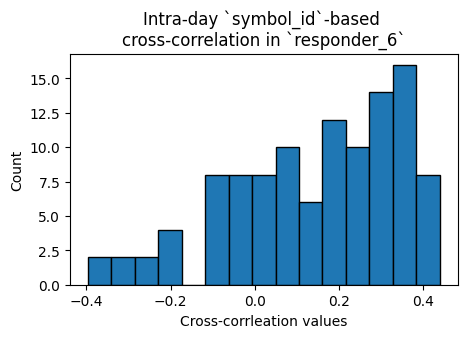

In [20]:
corr_matrix = correlation.to_numpy()

print(f'Max cross-correlation found = {max(abs(corr_matrix[corr_matrix != 1.]))}')

fig, axes = plt.subplots(1, 1, figsize=(5, 3))
axes.set_xlabel('Cross-corrleation values')
axes.set_ylabel('Count')
axes.set_title('Intra-day `symbol_id`-based \ncross-correlation in `responder_6`')
_ = axes.hist(corr_matrix[corr_matrix != 1.].flatten(),
              bins=15,
              edgecolor='k')

The presence of such moderate correlations suggest that, when modeling, it might be wiser to employ a model that takes the `symbol_id` as a feature, rather than creating a separate model per `symbol_id`. (Plus, that would avoid the possible issue of future data having `symbol_id` values that were not present in training)

### Step 4.4: Autocorrelation in `responder_6` based on `symbol_id`

Let's now evaluate the rolling autocorrelation in `responder_6`

Note that here, since the `'time_id'` entries are no uniformly distributed and not guaranteed to appear in the same amount on the same date, we will simply use an order-based autocorrelation, rather than time-based one.

In [21]:
import numpy as np

def compute_autocorr(x, lag=1):
    if len(x) <= lag:
        return np.nan
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]


symbols = train_0["symbol_id"].unique().tolist()
symbols_autocorr = dict.fromkeys(symbols)

for s in symbols:
    # Create entry
    symbols_autocorr[s] = []

    # Get relevant data
    sub = train_0[train_0["symbol_id"] == s].sort_values(
        ["date_id", "time_id"])["responder_6"].values

    # Compute autocorr
    for lag in range(1, 100):
        symbols_autocorr[s].append(compute_autocorr(sub, lag=lag))

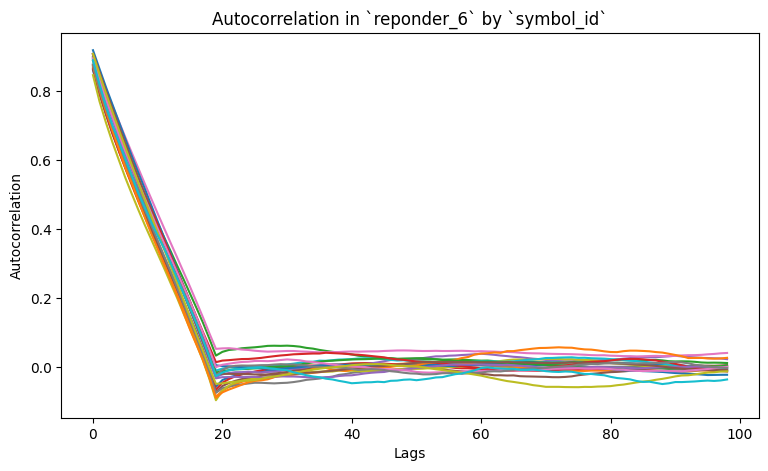

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(9, 5))
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelation')
axes.set_title('Autocorrelation in `reponder_6` by `symbol_id`')

for symbol, autocorr in symbols_autocorr.items():
    axes.plot(autocorr, label=symbol)

# _ = axes.legend(loc='upper right')

This is very interesting; it is heavily indicative that `responder_6` is some form of 20-step moving average.

## Step 5: Explore correlations between responders

### Step 5.1: General correlations

Let's first just check the general correlations in the responders.

In [23]:
# Get list of responders
responders = [name for name in train_0.columns if 'responder' in name]

# Compute correlation
responder_global_corr = train_0[responders].corr()

In [24]:
responder_global_corr['responder_6']

responder_0   -0.054535
responder_1   -0.025464
responder_2   -0.038340
responder_3    0.449509
responder_4    0.234051
responder_5    0.223958
responder_6    1.000000
responder_7    0.434894
responder_8    0.439424
Name: responder_6, dtype: float64

We can conclude from this that `responder_6` has moderate degrees of correlation with responders `3, 7, 8`, and slight correlation with responders `4, 5`. It appears to be uncorrelated with responders `0, 1, 2`. This suggests that perhaps a multi-target modeling may be beneficial.

#### Step 5.1.1: Per-symbol correlation

Let's briefly evaluate if the correlations change significantly on a per-symbol basis.

In [25]:
responder_6_corr_per_symbol = dict.fromkeys(symbols)

for symbol, symbol_date in train_0.groupby('symbol_id'):
    resp_corr = symbol_date[responders].corr()
    resp_6_corrs = resp_corr['responder_6'].to_list()
    # Delete the corr 6-to-6
    del resp_6_corrs[-3]
    responder_6_corr_per_symbol[symbol] = resp_6_corrs

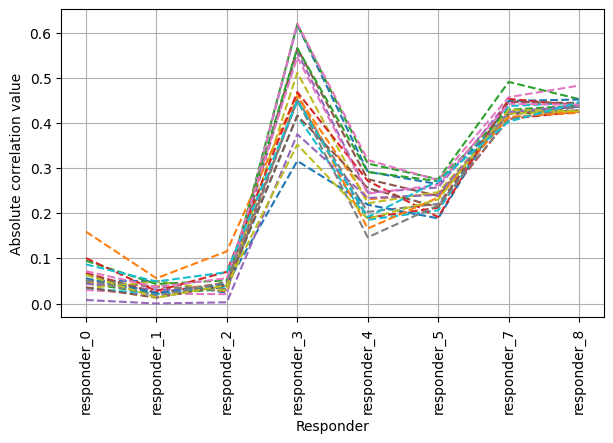

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(7,4))
axes.set_ylabel('Absolute correlation value')
axes.set_xlabel('Responder')
xticks = [responder for responder in responders if '6' not in responder]
axes.set_xticks(range(8))
axes.set_xticklabels(xticks, rotation=90)
axes.grid()

for symbol, corrs in responder_6_corr_per_symbol.items():
    axes.plot(np.abs(corrs),
              linestyle = '--',
              label=symbol)

We see that, overall, it is likely safe to ignore responders `0, 1, 2`, as they do not appear to be correlated with `responder_6`. We can also conclude that responders `7, 8` maintain about the same degree of moderate correlation with our target regardless of symbol. Interestingly, however, is that `responder_3` seems to have correlations varying from high (about 0.6) to moderate (about 0.3) depending on the symbol.

### Step 5.2: Closer look at higher correlations

Let's spend some more time investigating the moderate-to-high responder correlations a bit more carefully. 

Start with some basic plotting.

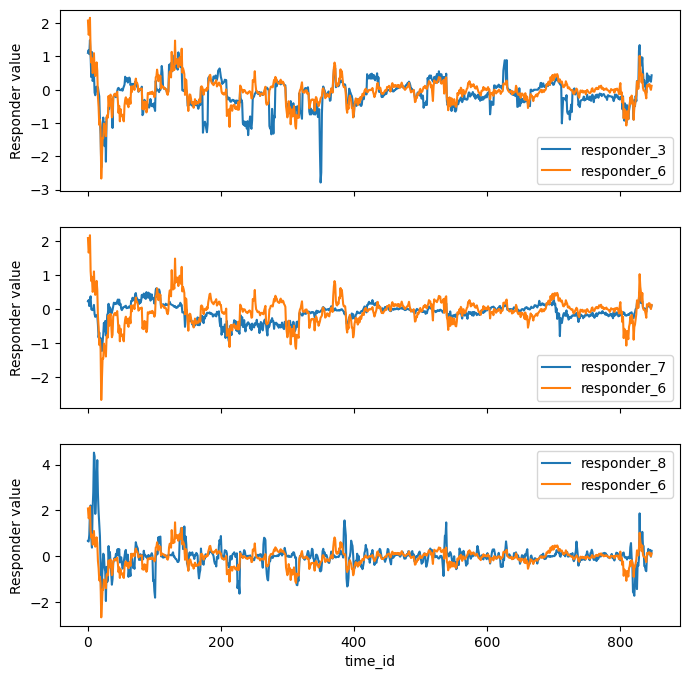

In [27]:
# Specify responders of interest
high_corr_resps = [f'responder_{i}' for i in [3, 7, 8]]

# Choose one symbol from the random data data
random_symbol = random_date_data['symbol_id'].sample(n=1).values[0]

# Get desired data
check_data_high_corr = random_date_data[random_date_data['symbol_id'] == random_symbol]

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
axes[-1].set_xlabel('time_id')

for ax, resp in zip(axes, high_corr_resps):
    ax.set_ylabel('Responder value')
    ax.plot(check_data_high_corr['time_id'],
              check_data_high_corr[resp],
              label=resp)
    ax.plot(check_data_high_corr['time_id'],
              check_data_high_corr['responder_6'],
              label='responder_6')
    _ = ax.legend()


We can see that `responder_3` and `responder_6` are, for the most part, well aligned, with occasional differences and spikes. This can be useful.

Some [online forum discussions](https://www.kaggle.com/competitions/jane-street-real-time-market-data-forecasting/discussion/555562) mentioned that responders `6, 7, 8` are likely moving averages of the same approximate signal, but with window sizes of 20, 120, and 4, respectively. 

Let's try to evaluation the validity of this.

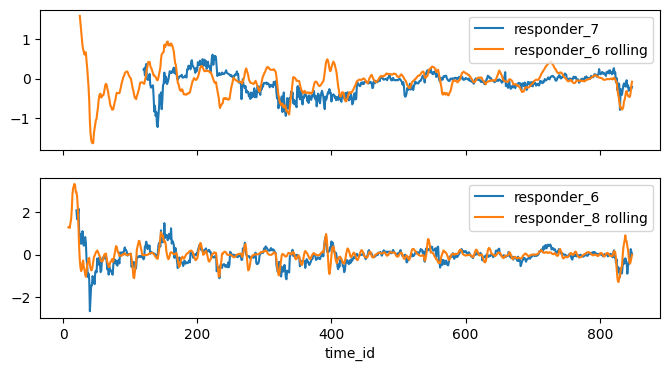

In [28]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 4))
axes[-1].set_xlabel('time_id')

# 6 and 7
axes[0].plot(check_data_high_corr['time_id'],
             check_data_high_corr['responder_7'].shift(120),
             label='responder_7')
axes[0].plot(check_data_high_corr['time_id'],
             check_data_high_corr['responder_6'].shift(20).rolling(6).mean(),
             label='responder_6 rolling')
_ = axes[0].legend()

# 6 and 8
axes[1].plot(check_data_high_corr['time_id'],
             check_data_high_corr['responder_6'].shift(20),
             label='responder_6')
axes[1].plot(check_data_high_corr['time_id'],
             check_data_high_corr['responder_8'].shift(4).rolling(window=5).mean(),
             label='responder_8 rolling')
_ = axes[1].legend()

I do not quite observe the same as in the online discussion, but it's not too far off, especially for `responder_6` and `responder_8`. 

Let's see if we observe anything in the lag-correlations.

In [29]:
def compute_lag_corr(x, y, lag):
    if lag != 0:
        return np.corrcoef(x[:-lag], y[lag:])[0, 1]
    return np.corrcoef(x, y)[0, 1]

# Dictionary to store info
lag_responder_corr_info_6 = dict.fromkeys(high_corr_resps)

for responder in high_corr_resps:
    lag_responder_corr_info_6[responder] = []
    for lag in range(100):
        lag_corr = compute_lag_corr(train_0['responder_6'].values,
                                    train_0[responder].values,
                                    lag=lag)
        lag_responder_corr_info_6[responder].append(lag_corr)

Brief sanity check:

In [30]:
for responder, lagged_corr in lag_responder_corr_info_6.items():
    print(f'{responder}: basic correlation = {lagged_corr[0]}')

responder_3: basic correlation = 0.4495089480953192
responder_7: basic correlation = 0.43489412721610077
responder_8: basic correlation = 0.43942403464156554


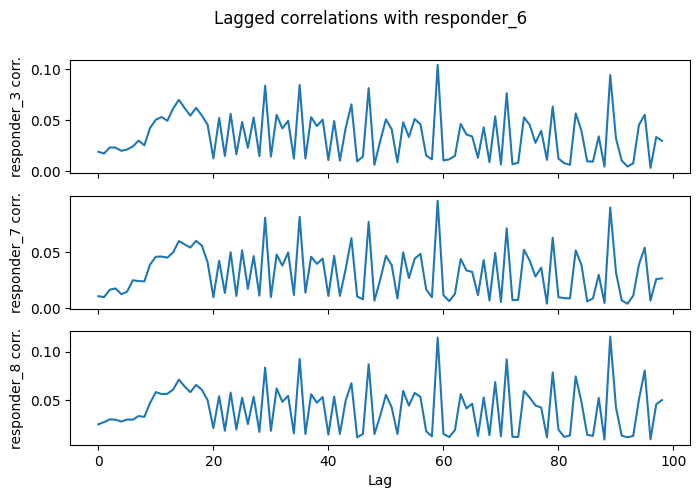

In [31]:
fig, axes = plt.subplots(len(high_corr_resps), 1, sharex='col', figsize=(8, 5))
axes[-1].set_xlabel('Lag')
fig.suptitle('Lagged correlations with responder_6')

for ax, (responder, lagged_corr) in zip(axes, lag_responder_corr_info_6.items()):
    ax.set_ylabel(f'{responder} corr.')
    _ = ax.plot(lagged_corr[1:])

Let's see if there is much change in the variation of each responder.

In [32]:
stats = train_0.groupby("symbol_id")[[
    "responder_3",
    "responder_6",
    "responder_7",
    "responder_8"
]].std()

print(stats)

           responder_3  responder_6  responder_7  responder_8
symbol_id                                                    
0             0.889098     0.672173     0.665318     0.760747
1             0.689156     0.635928     0.653002     0.687839
2             1.394107     0.870379     0.949741     0.854669
3             1.434677     1.080854     1.154022     1.050713
7             1.261639     0.873424     0.851064     0.936136
8             1.467403     0.897744     0.910214     0.851768
9             0.802665     0.718917     0.766550     0.717822
10            1.115568     0.808609     0.823474     0.884796
11            2.093300     1.162085     1.098180     1.086899
12            1.787776     0.935504     0.958725     0.893112
13            2.231351     1.038772     1.117115     0.887817
14            1.157354     0.959761     0.980228     0.977893
15            1.391593     1.181029     1.236793     1.247401
16            0.893709     0.776329     0.748932     0.828505
17      

Let's also see if their correlations change much on a day-to-day basis.

In [33]:
corr_by_date = train_0.groupby("date_id")[high_corr_resps + ['responder_6']].corr()

corr_to_6 = {}

for r in high_corr_resps:

    s = corr_by_date.loc[
        (slice(None), 'responder_6'),
        r
    ]

    s.index = s.index.droplevel(1)

    corr_to_6[r] = s

corr_to_6 = pd.DataFrame(corr_to_6)

In [34]:
corr_to_6.describe()

,responder_3,responder_7,responder_8
count,170.000000,170.000000,170.000000
mean,0.447958,0.430202,0.437300
std,0.100733,0.036220,0.025029
min,0.071254,0.341642,0.389495
25%,0.385404,0.406170,0.426299
50%,0.441181,0.433122,0.435728
75%,0.513329,0.451215,0.445096
max,0.730513,0.513835,0.683725


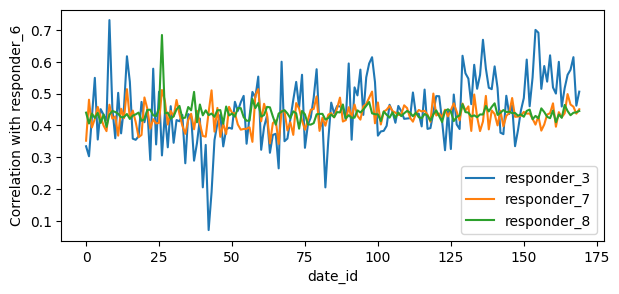

In [35]:
ax = corr_to_6.plot(figsize=(7, 3))
_ = ax.set_ylabel('Correlation with responder_6')

## Step 6: Understanding features

Let's now spend some time investigating the features provided, and how they relate to our target.

### Step 6.0: Recompute `NaN` prevalence

For consistency, recall the frequency of `NaN` entries.

In [36]:
nan_fraction_per_feature.head(10)

feature_00    1.000000
feature_21    1.000000
feature_02    1.000000
feature_03    1.000000
feature_04    1.000000
feature_01    1.000000
feature_31    1.000000
feature_27    1.000000
feature_26    1.000000
feature_42    0.167025
dtype: float64

Let's remove the features with all `NaN`.

In [37]:
bad_feats = []

for feature in feature_cols:
    if np.allclose(nan_fraction_per_feature[feature], 1):
        bad_feats.append(feature)

for bad_feat in bad_feats:
    feature_cols.remove(bad_feat)

print(f'Remaining features: {len(feature_cols)}')

Remaining features: 70


### Step 6.1: Look at the feature distributions

In [38]:
train_0[feature_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
feature_05,-0.044632,0.947958,-11.766080,15.319997
feature_06,-0.006456,0.935119,-25.143543,24.158113
feature_07,-0.019842,0.967365,-20.321791,28.097809
feature_08,0.059797,0.922840,-6.224619,13.068775
feature_09,28.628384,23.910034,4.000000,81.000000
...,...,...,...,...
feature_74,-0.120112,0.635200,-3.232666,36.516098
feature_75,-0.083468,0.759618,-4.003407,42.018932
feature_76,-0.084515,0.754082,-3.784688,41.826225
feature_77,-0.096821,0.649495,-3.693742,46.722252


It seems some values are very different from the others, and I fear some of these features may actually be categorical... Let's see if we can find out.

In [39]:
# Compute number of unique entries per feature
nunique = train_0[feature_cols].nunique()
nunique.sort_values(inplace=True, ascending=True)
unique_frac = nunique / len(train_0)


In [40]:
nunique.head(15)

feature_10          6
feature_09         11
feature_11         12
feature_61        170
feature_23       2290
feature_30       2290
feature_29       2290
feature_28       2290
feature_25       2290
feature_24       2290
feature_22       2290
feature_20       2290
feature_42    1594763
feature_39    1596004
feature_53    1632523
dtype: int64

It is clear that at least features `9, 10, 11` are categorical. It is not clear about `feature_61`, or even those with 2290 unique values. Let's investigate some more.

#### Step 6.1.1: Investigate categorical candidates

First, separate the obviously categorical ones.

In [41]:
categorical_features = nunique.index.values[:3].tolist()

Now, let's investigate the others. First, let's create an auxiliary function to check if a column is made up of integers mostly.

In [42]:
def is_integer_like(x: pd.Series) -> bool:
    x = x.dropna().values
    return np.all(np.isclose(x, np.round(x)))

# Check feature 61
is_integer_like(train_0['feature_61'])

np.False_

Ok, so `feature_61` is evidently not made up exclusively of integer values.

In [43]:
feat_61_val_counts = train_0['feature_61'].value_counts()

feat_61_val_counts.describe()

count      170.000000
mean     11436.529412
std       2769.502763
min       3396.000000
25%       9339.000000
50%      11461.500000
75%      13584.000000
max      16980.000000
Name: count, dtype: float64

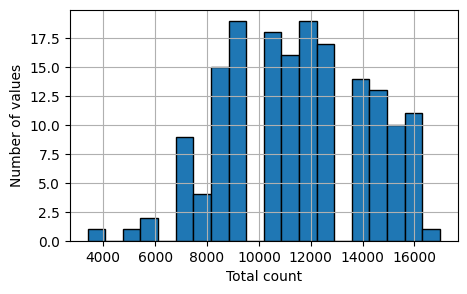

In [44]:
ax = feat_61_val_counts.hist(bins=20, edgecolor='k')
ax.set_ylabel('Number of values')
_ = ax.set_xlabel('Total count')

fig = ax.get_figure()
fig.set_figheight(3)
fig.set_figwidth(5)

In [45]:
train_0['feature_61'].diff().describe()

count    1.944209e+06
mean     8.551966e-07
std      1.049966e-02
min     -6.939452e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.624431e+00
Name: feature_61, dtype: float64

It appears `feature_61` is likely a discretized continuous feature, instead of a categorical one. We will assume that the other features with 2290 unique values are the same for now. 

### Step 6.2: Investigating correlations between features and target

Now, let's investigate the possible correlations between the features and the target.

#### Step 6.2.1: Global correlations

First, compute all correlations.

In [46]:
feature_correlations = train_0[feature_cols + ['responder_6']].corr()

Now, let's check just the ones with `responder_6`.

In [47]:
feats_corr_with_target = feature_correlations['responder_6'].drop('responder_6')
feats_corr_with_target.sort_values(ascending=False, inplace=True)
feats_corr_with_target.describe()

count    70.000000
mean     -0.000389
std       0.017607
min      -0.087681
25%      -0.004284
50%       0.001098
75%       0.004977
max       0.027078
Name: responder_6, dtype: float64

In [55]:
feats_corr_with_target.head(15)

feature_68    0.027078
feature_51    0.026465
feature_08    0.022325
feature_69    0.022006
feature_13    0.019468
feature_52    0.019101
feature_54    0.018571
feature_38    0.018021
feature_18    0.017867
feature_37    0.017838
feature_14    0.016198
feature_59    0.016044
feature_65    0.014706
feature_60    0.013723
feature_55    0.008626
Name: responder_6, dtype: float64

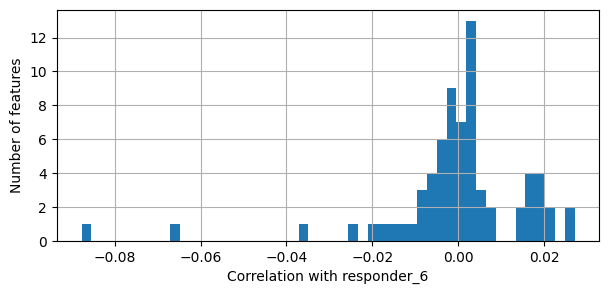

In [48]:
ax = feats_corr_with_target.hist(bins=50)

ax.set_ylabel('Number of features')
ax.set_xlabel('Correlation with responder_6')

fig = ax.get_figure()
fig.set_figheight(3)
fig.set_figwidth(7)

This indicates that perhaps none of our features are highly correlated to the target. However, maybe their correlation is symbol dependent...

#### Step 6.2.2: Correlations based on symbol

In [49]:
target = "responder_6"

corr_by_symbol = {}

for s, g in train_0.groupby("symbol_id"):

    corr = g[feature_cols + [target]].corr()[target].drop(target)

    corr_by_symbol[s] = corr

corr_by_symbol = pd.DataFrame(corr_by_symbol)

In [50]:
corr_stats = pd.DataFrame({
    "abs_mean": corr_by_symbol.abs().mean(axis=1),
    "signed_mean": corr_by_symbol.mean(axis=1),
    "std": corr_by_symbol.std(axis=1),
    "max": corr_by_symbol.max(axis=1),
    "min": corr_by_symbol.min(axis=1),
})

corr_stats.sort_values(by='abs_mean', ascending=False).head(10)

,abs_mean,signed_mean,std,max,min
feature_06,0.085414,-0.085414,0.024817,-0.046514,-0.124923
feature_07,0.062121,-0.062121,0.031319,-0.003807,-0.113667
feature_05,0.036111,-0.031744,0.026045,0.026769,-0.070259
feature_59,0.032673,0.021956,0.035721,0.105215,-0.041281
feature_60,0.030527,0.021991,0.036196,0.120070,-0.038841
feature_51,0.029176,0.029176,0.012744,0.055984,0.003964
feature_19,0.028065,-0.022126,0.026340,0.034631,-0.077015
feature_69,0.027191,0.012276,0.033354,0.070164,-0.040957
feature_45,0.025997,-0.014846,0.034678,0.100117,-0.072052
feature_38,0.025854,0.012171,0.030919,0.056739,-0.089452


It seems there is not much difference here, and the per-symbol correlations are somewhat similar to the global ones... 

#### Step 6.2.3: Time-varying symbol-based correlations

Let's see if maybe there is a temporal component to these correlations.

In [51]:
# group by date and symbol
date_symbol_groups = train_0.fillna(0.).groupby(["date_id", "symbol_id"])

# store correlations
corr_records_date_symbol = []

for (date, symbol), group in date_symbol_groups:
    if len(group) < 2:  # correlation undefined for <2 rows
        continue
    corr = group[feature_cols + [target]].corr()[target].drop(target)
    for feat, value in corr.items():
        corr_records_date_symbol.append({
            "date_id": date,
            "symbol_id": symbol,
            "feature": feat,
            "corr": value
        })

corr_records_date_symbol_df = pd.DataFrame(corr_records_date_symbol)
corr_records_date_symbol_df['abs_corr'] = corr_records_date_symbol_df['corr'].abs()


In [52]:
signed_summary = corr_records_date_symbol_df.groupby("feature")["corr"]\
    .agg(["mean", "std", "min", "max"]).sort_values("std", ascending=False)
abs_summary = corr_records_date_symbol_df.groupby("feature")["abs_corr"]\
    .agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False)
print(signed_summary.head(10))

                mean       std       min       max
feature                                           
feature_47  0.055770  0.165062 -0.611755  0.670925
feature_56  0.072413  0.162601 -0.564260  0.625939
feature_49  0.038094  0.161366 -0.628982  0.621230
feature_57  0.084691  0.155785 -0.487664  0.613108
feature_62 -0.004064  0.151284 -0.545871  0.579122
feature_45  0.068183  0.149525 -0.502172  0.674762
feature_64 -0.002893  0.148657 -0.607898  0.531468
feature_46  0.071792  0.147421 -0.408357  0.596627
feature_08  0.015191  0.146628 -0.482183  0.719967
feature_37 -0.170500  0.146563 -0.681534  0.321201


In [53]:
print(abs_summary.head(10))

                mean       std       min       max
feature                                           
feature_37  0.191836  0.117246  0.000161  0.681534
feature_38  0.185747  0.114404  0.000168  0.659644
feature_56  0.142997  0.105962  0.000048  0.625939
feature_57  0.142943  0.104897  0.000129  0.613108
feature_47  0.136913  0.107721  0.000090  0.670925
feature_45  0.132409  0.097308  0.000111  0.674762
feature_46  0.130468  0.099297  0.000170  0.596627
feature_49  0.129645  0.103323  0.000045  0.628982
feature_07  0.128142  0.093995  0.000009  0.537531
feature_58  0.126157  0.094671  0.000086  0.552216


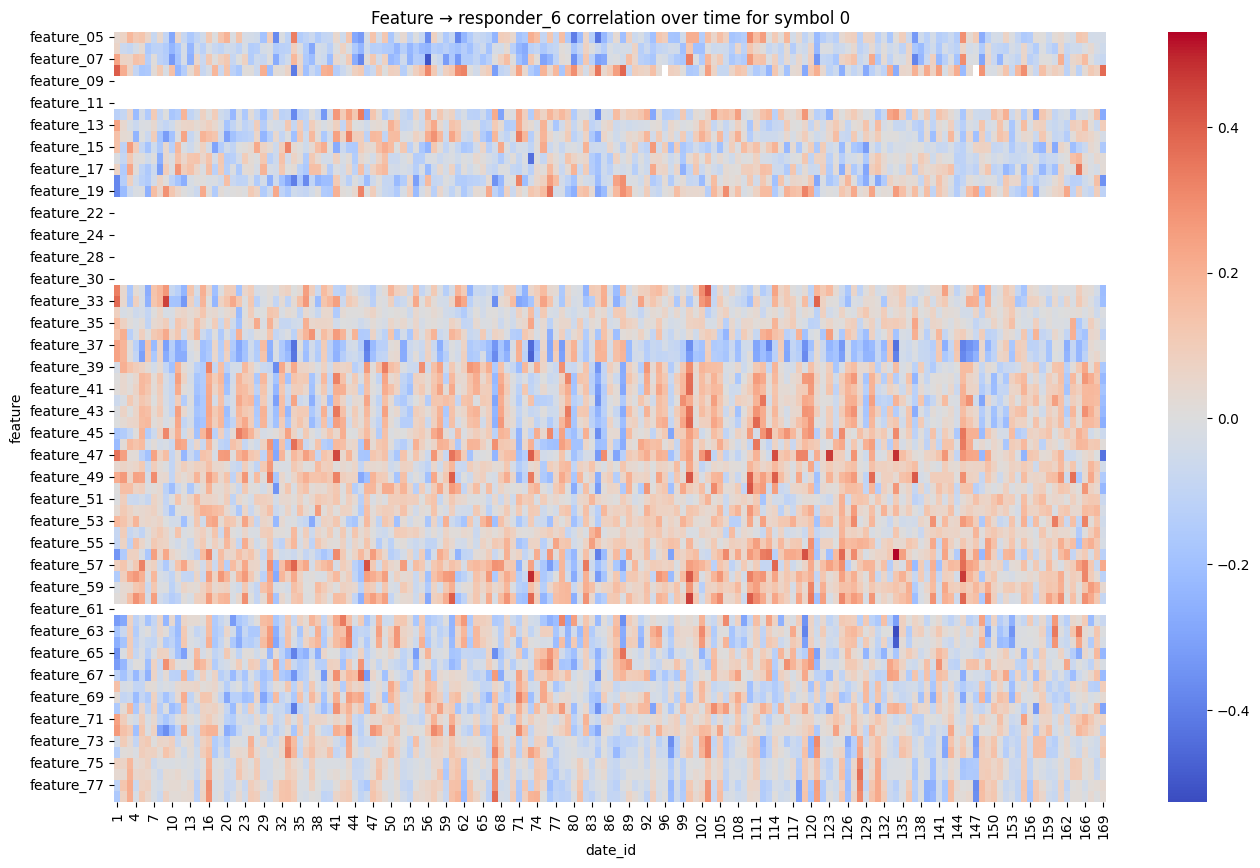

In [54]:
# pivot for heatmap
heatmap_data = corr_records_date_symbol_df[corr_records_date_symbol_df["symbol_id"]==0].pivot(
    index="feature",
    columns="date_id",
    values="corr")
plt.figure(figsize=(16,10))
sns.heatmap(heatmap_data, center=0.0, cmap="coolwarm")
plt.title("Feature → responder_6 correlation over time for symbol 0")
plt.show()

## Step 7: Understand the test and lagged response

Let's now just load the test response (which mocks what is served by the API), as well as the lagged response.

### Step 7.1: Test

In [56]:
test_data = pd.read_parquet(data_dir / 'test.parquet/date_id=0/part-0.parquet')

test_data.head(5)

,row_id,date_id,time_id,symbol_id,weight,is_scored,feature_00,feature_01,feature_02,feature_03,...,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78
0,0,0,0,0,3.169998,False,0.0,0.0,0.0,0.0,...,-0.0,-0.0,0.0,0.0,NaN,NaN,0.0,0.0,-0.0,-0.0
1,1,0,0,1,2.165993,False,0.0,-0.0,0.0,0.0,...,-0.0,-0.0,0.0,-0.0,NaN,NaN,0.0,0.0,0.0,0.0
2,2,0,0,2,3.065550,False,0.0,-0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,NaN,NaN,0.0,0.0,-0.0,-0.0
3,3,0,0,3,2.698642,False,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,NaN,NaN,0.0,0.0,-0.0,-0.0
4,4,0,0,4,1.803330,False,0.0,-0.0,0.0,0.0,...,-0.0,-0.0,0.0,-0.0,NaN,NaN,0.0,0.0,0.0,0.0


In [57]:
test_date_ids = test_data['date_id'].unique()
test_time_ids = test_data['time_id'].unique()

print(f'Date_ids: {test_date_ids}')
print(f'Time_ids: {test_time_ids}')

Date_ids: [0]
Time_ids: [0]


In [59]:
print(f"Num symbols = {len(test_data['symbol_id'].unique())}")

Num symbols = 39


As we can see, the test contains data for a single "timestamp" (`date_id, time_id` pair).

### Step 7.2: Lags

In [63]:
lagged_data = pd.read_parquet(data_dir / 'lags.parquet/date_id=0/part-0.parquet')

lagged_data.head(10)

,date_id,time_id,symbol_id,responder_0_lag_1,responder_1_lag_1,responder_2_lag_1,responder_3_lag_1,responder_4_lag_1,responder_5_lag_1,responder_6_lag_1,responder_7_lag_1,responder_8_lag_1
0,0,0,0,-0.442215,-0.322407,0.143594,-0.926890,-0.782236,-0.036595,-1.305746,-0.795677,-0.143724
1,0,0,1,-0.651829,-1.707840,-0.893942,-1.065488,-1.871338,-0.615652,-1.162801,-1.205924,-1.245934
2,0,0,2,-0.656373,-0.264575,-0.892879,-1.511886,-1.033480,-0.378265,-1.574290,-1.863071,-0.027343
3,0,0,3,-0.188186,-0.190970,-0.701490,0.098453,-1.015506,-0.054984,0.329152,-0.965471,0.576635
4,0,0,4,-0.257462,-0.471325,-0.297420,0.074018,-0.324194,-0.597093,0.219856,-0.276356,-0.904790
5,0,0,5,0.027579,-0.020169,0.640348,-0.948373,-0.374251,-0.240350,-0.913801,-0.548867,-1.283726
6,0,0,6,-0.419646,-0.181228,-0.194079,0.667993,0.936857,0.517728,0.896325,1.068884,1.579290
7,0,0,7,-0.114118,-0.198511,-0.200027,-0.410021,-0.135167,-0.182887,-0.492168,-0.142915,-0.202081
8,0,0,8,-0.374147,0.092127,0.294723,0.402989,2.060188,-0.225042,0.956460,2.185598,-0.435856
9,0,0,9,-0.529529,0.040104,-0.333090,-0.959040,-1.318411,-0.774299,-0.716492,-1.471419,-1.107083


Ennsure it has the same symbol IDs as in the test:

In [65]:
for symbol_id in lagged_data['symbol_id']:
    assert symbol_id in test_data['symbol_id'], f'Missing {symbol_id}!'